### Extreme Value Distributions

The maximum of many random variables has its own distributional behavior. This notebook derives and plots the distribution of maxima from normal samples, showing how the density shifts and concentrates as the number of draws grows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

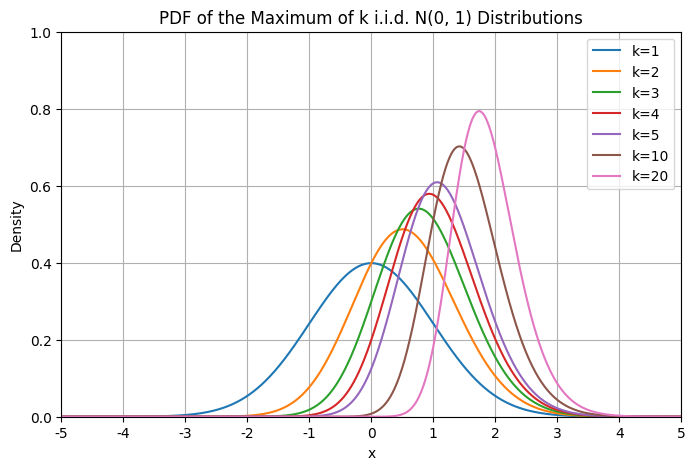

In [18]:
# Define the range of x values
x = np.linspace(-5, 5, 1000)

# Values of k
k_values = [1, 2, 3, 4, 5, 10, 20]

# Plot the PDFs for different values of k
plt.figure(figsize=(8, 5))

for k in k_values:
    # CDF of a single N(0, 1) raised to the power of k
    cdf_k = stats.norm.cdf(x) ** k
    
    # Differentiating the CDF to get the PDF
    pdf_k = k * stats.norm.cdf(x) ** (k - 1) * stats.norm.pdf(x)
    
    plt.plot(x, pdf_k, label=f'k={k}')

plt.title('PDF of the Maximum of k i.i.d. N(0, 1) Distributions')
plt.xlabel('x')
plt.xlim(-5, 5)
plt.xticks(np.arange(-5, 6), np.arange(-5, 6))
plt.ylabel('Density')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

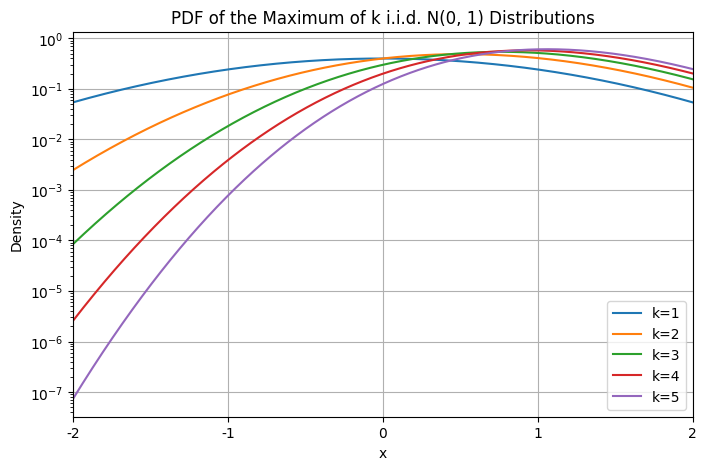

In [26]:
# Define the range of x values
x = np.linspace(-2, 2, 1000)

# Values of k
k_values = [1, 2, 3, 4, 5]

# Plot the PDFs for different values of k
plt.figure(figsize=(8, 5))

for k in k_values:
    # CDF of a single N(0, 1) raised to the power of k
    cdf_k = stats.norm.cdf(x) ** k
    
    # Differentiating the CDF to get the PDF
    pdf_k = k * stats.norm.cdf(x) ** (k - 1) * stats.norm.pdf(x)
    
    plt.plot(x, pdf_k, label=f'k={k}')

plt.title('PDF of the Maximum of k i.i.d. N(0, 1) Distributions')
plt.xlabel('x')
plt.xlim(-2, 2)
plt.xticks(np.arange(-2, 3), np.arange(-2, 3))
plt.ylabel('Density')
plt.yscale('log')
plt.legend()
plt.grid(True)


In [3]:
# Increasing the number of simulations to 100,000
num_simulations = 100_000

# Dictionary to store the estimated statistics
stats_estimates = {"k": [], "Mean": [], "Standard Deviation": [], "Skewness": [], "Kurtosis": []}

# Perform simulations
k_max = 20
for k in np.arange(1, k_max+1):
    # Generate a matrix of size num_simulations x k of standard normal random variables
    samples = np.random.normal(0, 1, (num_simulations, k))
    
    # Find the maximum of each row (i.e., each set of k variables)
    maxima = np.max(samples, axis=1)
    
    # Calculate the required statistics
    stats_estimates["k"].append(k)
    stats_estimates["Mean"].append(np.mean(maxima))
    stats_estimates["Standard Deviation"].append(np.std(maxima))
    stats_estimates["Skewness"].append(stats.skew(maxima))
    stats_estimates["Kurtosis"].append(stats.kurtosis(maxima))

stats_estimates_df = pd.DataFrame.from_records(stats_estimates, columns=stats_estimates.keys())
stats_estimates_df



,k,Mean,Standard Deviation,Skewness,Kurtosis
0,1,0.001326,0.994992,-0.002867,-0.024261
1,2,0.562710,0.824989,0.141482,0.064753
2,3,0.843960,0.746607,0.211972,0.146075
3,4,1.030851,0.702504,0.275669,0.180835
4,5,1.162837,0.668554,0.305095,0.214258
5,6,1.269292,0.647525,0.338680,0.232947
6,7,1.348753,0.625426,0.355127,0.279724
7,8,1.419276,0.607880,0.376720,0.293947
8,9,1.487145,0.595814,0.395049,0.321459
9,10,1.538579,0.586066,0.404608,0.324118


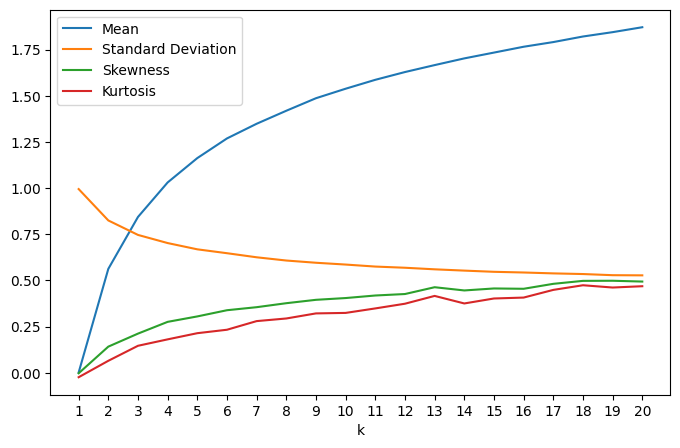

In [4]:
plt.figure(figsize=(8, 5))
for column in ['Mean', 'Standard Deviation', 'Skewness', 'Kurtosis']:
    plt.plot(stats_estimates_df['k'], stats_estimates_df[column], label=column)
plt.legend()
plt.xlabel('k')
plt.xticks(np.arange(1, k_max+1), np.arange(1, k_max+1));